# AudioMAE - Masked Autoencoder Reconstruction Demo

Este notebook demuestra la **reconstrucción de audio** usando el modelo pre-entrenado de
[Masked Autoencoders that Listen](https://arxiv.org/abs/2207.06405) (NeurIPS 2022).

### ¿Qué hace?
1. Toma un archivo de audio (`.wav`)
2. Lo convierte a un **mel-spectrogram**
3. Enmascara **parches aleatorios** del espectrograma
4. El **autoencoder MAE** reconstruye las partes faltantes
5. Visualizamos: original → enmascarado → reconstruido → combinación

### Checkpoint necesario
Usamos el checkpoint **pre-trained** de ViT-B en AudioSet-2M
([Google Drive](https://drive.google.com/file/d/1ni_DV4dRf7GxM8k-Eirx71WP9Gg89wwu))

---
## 1. Instalación de dependencias

In [1]:
# Instalamos dependencias compatibles
# Nota: timm 0.4.12 tiene Block con qk_scale (necesario para AudioMAE)
!pip install timm==0.4.12 matplotlib librosa gdown --quiet

# Chequeamos que torch/torchaudio estén instalados
import torch
import torchaudio
print(f"PyTorch {torch.__version__}")
print(f"Torchaudio {torchaudio.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

You should consider upgrading via the 'C:\Users\juan_\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


PyTorch 2.12.0+cpu
Torchaudio 2.11.0+cpu
CUDA available: False


In [2]:
# Verificamos versión de timm
import timm
print(f"timm {timm.__version__}")

# Test rápido de que Block existe con qk_scale
from timm.models.vision_transformer import Block
import inspect
sig = inspect.signature(Block.__init__)
print(f"Block acepta qk_scale: {'qk_scale' in sig.parameters}")

c:\Users\juan_\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


timm 0.4.12
Block acepta qk_scale: False


---
## 2. Clonar el repo y parchear imports

In [3]:
# Parche ÚNICO: Adaptado para Windows / Entorno Local
import os
import shutil
import sys

# Detectamos la ruta actual automáticamente en lugar de usar /content
CWD = os.getcwd()
REPO_DIR = os.path.join(CWD, 'AudioMAE')
base = REPO_DIR

# 0) Re-clonar para partir siempre desde archivos originales
print('0/5 Re-clonando repo...')
os.chdir(CWD)  # Aseguramos estar en la raíz antes de borrar

# Si la carpeta ya existe, la borramos para limpiar
if os.path.exists(base):
    try:
        shutil.rmtree(base)
    except PermissionError:
        print("⚠️ Alerta: No se pudo borrar la carpeta anterior por permisos. Se sobreescribirán los archivos.")

# Clonamos usando una llamada limpia compatible con Windows
print(f"Clonando en: {base}")
os.system(f'git clone https://github.com/facebookresearch/AudioMAE.git "{base}"')

# Entramos al repositorio recién clonado
os.chdir(base)
sys.path.insert(0, base)

# 1) models_mae.py: Swin comentado, cuda, qk_scale
models_mae_path = os.path.join(base, 'models_mae.py')
if os.path.exists(models_mae_path):
    with open(models_mae_path, 'r', encoding='utf-8') as f:
        c = f.read()
    c = c.replace("from timm.models.swin_transformer import SwinTransformerBlock",
                  "# from timm.models.swin_transformer import SwinTransformerBlock  # commented out for compatibility")
    c = c.replace("loss_contrastive = torch.FloatTensor([0.0]).cuda()",
                  "loss_contrastive = torch.FloatTensor([0.0]).to(imgs.device)")
    c = c.replace(", qk_scale=None", "")  # saca TODOS los qk_scale del archivo
    with open(models_mae_path, 'w', encoding='utf-8') as f:
        f.write(c)
    print('1/4 models_mae.py OK')
else:
    print('❌ Error: No se encontró models_mae.py. ¿El git clone falló?')

# 2) util/misc.py: torch._six
misc_path = os.path.join(base, 'util', 'misc.py')
if os.path.exists(misc_path):
    with open(misc_path, 'r', encoding='utf-8') as f:
        c = f.read()
    c = c.replace('from torch._six import inf', 'from math import inf')
    with open(misc_path, 'w', encoding='utf-8') as f:
        f.write(c)
    print('2/4 misc.py OK')

# 3) util/pos_embed.py: np.float deprecated en NumPy 1.24+
import re
pos_embed_path = os.path.join(base, 'util', 'pos_embed.py')
if os.path.exists(pos_embed_path):
    with open(pos_embed_path, 'r', encoding='utf-8') as f:
        c = f.read()
    c = re.sub(r'np\.float\b', 'float', c)  # reemplaza np.float pero NO np.float32
    with open(pos_embed_path, 'w', encoding='utf-8') as f:
        f.write(c)
    print('3/4 pos_embed.py OK')

# 4) timm helpers.py: container_abcs
try:
    import timm
    hp = os.path.join(os.path.dirname(timm.__file__), 'models', 'layers', 'helpers.py')
    if os.path.exists(hp):
        with open(hp, 'r', encoding='utf-8') as f:
            c = f.read()
        if 'torch._six' in c:
            c = c.replace('from torch._six import container_abcs',
                          'import collections.abc as container_abcs')
            with open(hp, 'w', encoding='utf-8') as f:
                f.write(c)
            print('4/4 timm helpers OK')
        else:
            print('4/4 timm helpers ya limpio')
    else:
        print('4/4 helpers no existe (OK)')
except ImportError:
    print('4/4 timm no está instalado en este entorno virtual (Sáltalo si no usas timm externo)')

print('\nTODO LISTO. Ya podés ejecutar el entrenamiento del modelo localmente.')

0/5 Re-clonando repo...
⚠️ Alerta: No se pudo borrar la carpeta anterior por permisos. Se sobreescribirán los archivos.
Clonando en: c:\Users\juan_\Downloads\AudioMAE
1/4 models_mae.py OK
2/4 misc.py OK
3/4 pos_embed.py OK
4/4 timm helpers ya limpio

TODO LISTO. Ya podés ejecutar el entrenamiento del modelo localmente.


In [4]:
import os
import sys

# Aseguramos que herede el REPO_DIR local del paso anterior
# Si estás corriendo esto en una celda separada, descomenta la línea de abajo:
# REPO_DIR = os.path.join(os.getcwd(), 'AudioMAE')

CKPT_DIR = os.path.join(REPO_DIR, 'ckpt')
os.makedirs(CKPT_DIR, exist_ok=True)

# Pre-trained checkpoint (ViT-B, AudioSet-2M) - 330MB (o superior según el drive)
FILE_ID = '1ni_DV4dRf7GxM8k-Eirx71WP9Gg89wwu'
CKPT_PATH = os.path.join(CKPT_DIR, 'pretrained.pth')

def download_checkpoint(path, file_id):
    """Intenta descargar de Google Drive usando gdown de forma nativa multiplataforma."""
    # Estrategia 1: gdown nativo
    try:
        import gdown
        print("Intentando con gdown...")
        url = f'https://drive.google.com/uc?id={file_id}'
        
        # gdown maneja de forma nativa los redireccionamientos y confirmaciones en Windows/Linux/Mac
        gdown.download(url, path, quiet=False, fuzzy=True)
        
        if os.path.exists(path) and os.path.getsize(path) > 1e6:
            return True
    except Exception as e:
        print(f"  gdown falló o no está instalado: {e}")
    
    # Estrategia 2: Alternativa nativa con requests (si gdown falla por cuotas)
    try:
        import requests
        print("Intentando descarga directa alternativa vía requests...")
        url = f'https://drive.google.com/uc?id={file_id}&export=download'
        session = requests.Session()
        response = session.get(url, stream=True)
        
        # Confirmación de advertencia de archivos grandes de Google Drive
        token = None
        for key, value in response.cookies.items():
            if key.startswith('download_warning'):
                token = value
                break
        
        if token:
            url = url + f'&confirm={token}'
            response = session.get(url, stream=True)
            
        with open(path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=32768):
                if chunk:
                    f.write(chunk)
                    
        if os.path.exists(path) and os.path.getsize(path) > 1e6:
            return True
    except Exception as e:
        print(f"  Estrategia de respaldo falló: {e}")
        
    return False

# Verificación y ejecución
if not os.path.exists(CKPT_PATH) or os.path.getsize(CKPT_PATH) < 1e6:
    print("=" * 60)
    print("DESCARGANDO CHECKPOINT PRE-TRAINED")
    print("Esto puede tomar unos minutos...")
    print("Link directo: https://drive.google.com/file/d/1ni_DV4dRf7GxM8k-Eirx71WP9Gg89wwu")
    print("=" * 60)
    
    success = download_checkpoint(CKPT_PATH, FILE_ID)
    
    if success:
        print(f"✅ Descarga completada: {os.path.getsize(CKPT_PATH)/1024/1024:.1f} MB")
    else:
        print("\n⚠️ No se pudo descargar automáticamente debido a las restricciones de Google Drive.")
        print("Por favor, descárgalo manualmente desde tu navegador en este link:")
        print("  https://drive.google.com/file/d/1ni_DV4dRf7GxM8k-Eirx71WP9Gg89wwu")
        print(f"\nLuego, mueve el archivo descargado y guárdalo exactamente en:\n➡️  {CKPT_PATH}")
else:
    print(f"✅ Checkpoint ya existe en tu entorno local: {os.path.getsize(CKPT_PATH)/1024/1024:.1f} MB")

✅ Checkpoint ya existe en tu entorno local: 1563.1 MB


---
## 4. Descargar audio de ejemplo

Usamos un sample del dataset ESC-50 (gratuito, CC license).
Podés **subir tu propio audio** más abajo si preferís.

In [6]:
import urllib.request

SAMPLE_DIR = os.path.join(REPO_DIR, 'demo_audio')
os.makedirs(SAMPLE_DIR, exist_ok=True)

# Sample de ESC-50: perro ladrando
sample_url = 'https://github.com/karolpiczak/ESC-50/raw/master/audio/1-100038-A-14.wav'
sample_path = os.path.join(SAMPLE_DIR, 'sample_dog_bark.wav')

if not os.path.exists(sample_path):
    print("Descargando audio de ejemplo (dog bark)...")
    urllib.request.urlretrieve(sample_url, sample_path)
    print("Descarga completada")
else:
    print(f"Audio ya existe: {sample_path}")

# También podemos usar un sample de torchaudio
torchaudio_sample = os.path.join(SAMPLE_DIR, 'speech_sample.wav')
if not os.path.exists(torchaudio_sample):
    print("Descargando sample de voz...")
    try:
        import urllib.request
        # Yes/no sample de LibriSpeech
        speech_url = 'https://www.nasa.gov/wp-content/uploads/2023/03/apollo-11-wakeup-call.wav'
        urllib.request.urlretrieve(speech_url, torchaudio_sample)
        print("Sample de voz descargado")
    except Exception as e:
        print(f"No se pudo descargar sample de voz: {e}")

Audio ya existe: c:\Users\juan_\Downloads\AudioMAE\demo_audio\sample_dog_bark.wav
Descargando sample de voz...
No se pudo descargar sample de voz: HTTP Error 404: Not Found


In [7]:
# Listar audios disponibles
import glob
audio_files = glob.glob(os.path.join(SAMPLE_DIR, '*.wav'))
print("Audios disponibles:")
for i, f in enumerate(audio_files):
    print(f"  {i}: {os.path.basename(f)} ({os.path.getsize(f)/1024:.1f} KB)")

Audios disponibles:
  0: sample_dog_bark.wav (430.7 KB)


---
## 5. Pipeline de preprocesado

Convertimos el audio a mel-spectrogram usando los mismos parámetros que el paper:
- 128 mel bands (frecuencia)
- 1024 frames (tiempo)
- Kaldi FBANK con frame_shift=10ms
- Normalización con media -4.27 y std 4.57

In [8]:
import torch
import torchaudio
from torchaudio.compliance import kaldi
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del paper
MELBINS = 128
TARGET_LEN = 1024  # para AudioSet (10ms x 1024 = ~10s a 16kHz)
NORM_MEAN = -4.2677393
NORM_STD = 4.5689974

def wav2fbank(filename):
    """Convierte un .wav a mel-spectrogram (time, freq).
    Si el audio es corto (< TARGET_LEN frames), lo repite para
    evitar zero-padding (que empeora la reconstrucción).
    """
    waveform, sr = torchaudio.load(filename)
    
    # Si es stereo, pasamos a mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    
    # Normalización DC
    waveform = waveform - waveform.mean()
    
    # Si el audio es corto (< 10s), repetir para llenar TARGET_LEN
    target_seconds = TARGET_LEN * 0.01  # frame_shift=10ms -> 10.24s
    target_samples = int(target_seconds * sr)
    actual_samples = waveform.shape[1]
    if actual_samples < target_samples:
        repeats = int(target_samples / actual_samples) + 1
        waveform = waveform.repeat(1, repeats)
        waveform = waveform[:, :target_samples]  # cortar exacto
        print(f"Audio repetido {repeats}x para alcanzar ~10s")
    
    # Mel-spectrogram via Kaldi FBANK
    fbank = kaldi.fbank(
        waveform,
        htk_compat=True,
        sample_frequency=sr,
        use_energy=False,
        window_type='hanning',
        num_mel_bins=MELBINS,
        dither=0.0,
        frame_shift=10
    )
    
    # Pad o cut a TARGET_LEN frames
    n_frames = fbank.shape[0]
    p = TARGET_LEN - n_frames
    if p > 0:
        m = torch.nn.ZeroPad2d((0, 0, 0, p))
        fbank = m(fbank)
    elif p < 0:
        fbank = fbank[0:TARGET_LEN, :]
    
    return fbank

def norm_fbank(fbank):
    """Normaliza el mel-spectrogram."""
    return (fbank - NORM_MEAN) / (NORM_STD * 2)

def denorm_fbank(fbank):
    """Desnormaliza (para visualización)."""
    return fbank * (NORM_STD * 2) + NORM_MEAN

def display_fbank(bank, title="", minmin=None, maxmax=None, ax=None):
    """Muestra el mel-spectrogram normalizado respetando la escala estadística."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 4))
        
    # Extraemos los datos a numpy de forma segura si viene como Tensor
    data = bank.detach().cpu().numpy() if isinstance(bank, torch.Tensor) else bank
    
    # Si las dimensiones vienen como (Time, Freq), transponemos a (Freq, Time) para imshow
    if data.shape[0] == 1024 or data.shape[0] == 600: # Si el eje de tiempo es el primero
        data = data.T
        
    # 🌟 ELIMINAMOS EL '* 20' QUE QUEMABA EL COLOR: Graficamos el valor real
    ax.imshow(data, origin='lower', interpolation='nearest',
              vmax=maxmax, vmin=minmin, aspect='auto', cmap='viridis')
    
    ax.set_xlabel('Time frame')
    ax.set_ylabel('Mel band')
    if title:
        ax.set_title(title)
    return ax

print("✅ Función display_fbank corregida y calibrada.")

✅ Función display_fbank corregida y calibrada.


---
## 6. Cargar el modelo MAE pre-entrenado

In [9]:
import os
if os.path.exists(CKPT_PATH):
    os.remove(CKPT_PATH)
    print("Archivo corrupto eliminado con éxito.")

Archivo corrupto eliminado con éxito.


In [11]:
import torch
import models_mae
import pathlib  # <-- PASO 1: Importamos pathlib

# Truco mágico para Windows: mapear PosixPath a WindowsPath
# Esto evita el error NotImplementedError: cannot instantiate 'PosixPath'
pathlib.PosixPath = pathlib.WindowsPath

# Asegúrate de que estas variables mantengan los valores de tu arquitectura
TARGET_LEN = 1024  
MELBINS = 128     

def prepare_model(chkpt_dir, arch='mae_vit_base_patch16'):
    """Construye el modelo MAE y carga los pesos pre-entrenados parcheando rutas de Linux."""
    print(f"Construyendo modelo: {arch}...")
    
    model = getattr(models_mae, arch)(
        in_chans=1,
        audio_exp=True,
        img_size=(TARGET_LEN, MELBINS)
    )
    
    import os
    if not os.path.exists(chkpt_dir):
        raise FileNotFoundError(f"❌ No se encontró el archivo de pesos en: {chkpt_dir}.")
    
    # PASO 2: Cargamos el mapa de pesos (Ahora con el parche de pathlib activo)
    print("Cargando pesos del checkpoint (aplicando parche de compatibilidad OS)...")
    checkpoint = torch.load(chkpt_dir, map_location='cpu', weights_only=False)
    
    if 'model' in checkpoint:
        state_dict = checkpoint['model']
    else:
        state_dict = checkpoint
    
    msg = model.load_state_dict(state_dict, strict=False)
    print(f"Missing keys: {len(msg.missing_keys)}")
    print(f"Unexpected keys: {len(msg.unexpected_keys)}")
    
    if len(msg.missing_keys) > 0:
        print("\n⚠️  ATENCIÓN: Al modelo le faltan pesos. Puede ser fine-tuned (sin decoder).")
    elif len(msg.unexpected_keys) > 0:
        print(f"✅ Checkpoint pre-trained cargado. {len(msg.unexpected_keys)} keys extras ignoradas.")
    else:
        print("✅ Checkpoint pre-trained cargado correctamente.")
    
    return model

# Ejecución del modelo modificado
model = prepare_model(CKPT_PATH, 'mae_vit_base_patch16')
model.eval()

# Mover el modelo a GPU (CUDA) si está disponible
if torch.cuda.is_available():
    model = model.cuda()
    print("🚀 Modelo enviado con éxito a la GPU (CUDA).")
else:
    print("💻 Corriendo el modelo en la CPU.")

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
print(f"\nParámetros totales: {total_params/1e6:.2f}M")

Construyendo modelo: mae_vit_base_patch16...
Cargando pesos del checkpoint (aplicando parche de compatibilidad OS)...
Missing keys: 0
Unexpected keys: 176
✅ Checkpoint pre-trained cargado. 176 keys extras ignoradas.
💻 Corriendo el modelo en la CPU.

Parámetros totales: 111.66M


---
## 7. Seleccionar audio y preprocesar

In [12]:
import os
import urllib.request
import torch
import soundfile as sf
import torchaudio
import matplotlib.pyplot as plt

# =====================================================================
# 1. FUNCIÓN WAV2FBANK ULTRA SEGURA (Inmune a bugs de TorchCodec)
# =====================================================================
def wav2fbank_seguro(filename):
    """Convierte un .wav a mel-spectrogram usando Soundfile nativo para evitar fallos de backend."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"No se encuentra el audio en: {filename}")
        
    # Leer audio usando soundfile puro
    data, samplerate = sf.read(filename)
    
    # Convertir a Tensor de PyTorch (canales, muestras)
    waveform = torch.FloatTensor(data)
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)  # (1, muestras)
    else:
        waveform = waveform.t()  # (canales, muestras)
        
    # Forzar a Mono si es estéreo
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
        
    # Normalización DC básica
    waveform = waveform - waveform.mean()
    
    # Si el audio es corto (< 10s), repetir para llenar TARGET_LEN
    target_length = 1024  # TARGET_LEN oficial
    target_seconds = target_length * 0.01  # frame_shift=10ms -> 10.24s
    target_samples = int(target_seconds * samplerate)
    actual_samples = waveform.shape[1]
    
    if actual_samples < target_samples:
        repeats = int(target_samples / actual_samples) + 1
        waveform = waveform.repeat(1, repeats)
        waveform = waveform[:, :target_samples]
    
    # Multiplicar por 16-bit PCM scale para que Kaldi fbank reaccione bien
    waveform = waveform * 32768.0
    
    # Calcular espectrograma Mel usando parámetros estándar de AudioMAE
    fbank_out = torchaudio.compliance.kaldi.fbank(
        waveform,
        htk_compat=True,
        sample_frequency=samplerate,
        use_energy=False,
        window_type='hanning',
        num_mel_bins=128,  # MELBINS
        dither=0.0,
        frame_shift=10
    )
    
    # Asegurar exactamente TARGET_LEN frames
    n_frames = fbank_out.shape[0]
    if n_frames < target_length:
        p = target_length - n_frames
        m = torch.nn.ZeroPad2d((0, 0, 0, p))
        fbank_out = m(fbank_out)
    else:
        fbank_out = fbank_out[:target_length, :]
        
    return fbank_out

El archivo de entrenamiento ya existe localmente.
Procesando: c:\Users\juan_\Downloads\AudioMAE\sample_dog_bark_entrenamiento.wav
Forma del espectrograma: torch.Size([1024, 128])
Min normalizado: 0.47, Max normalizado: 3.69


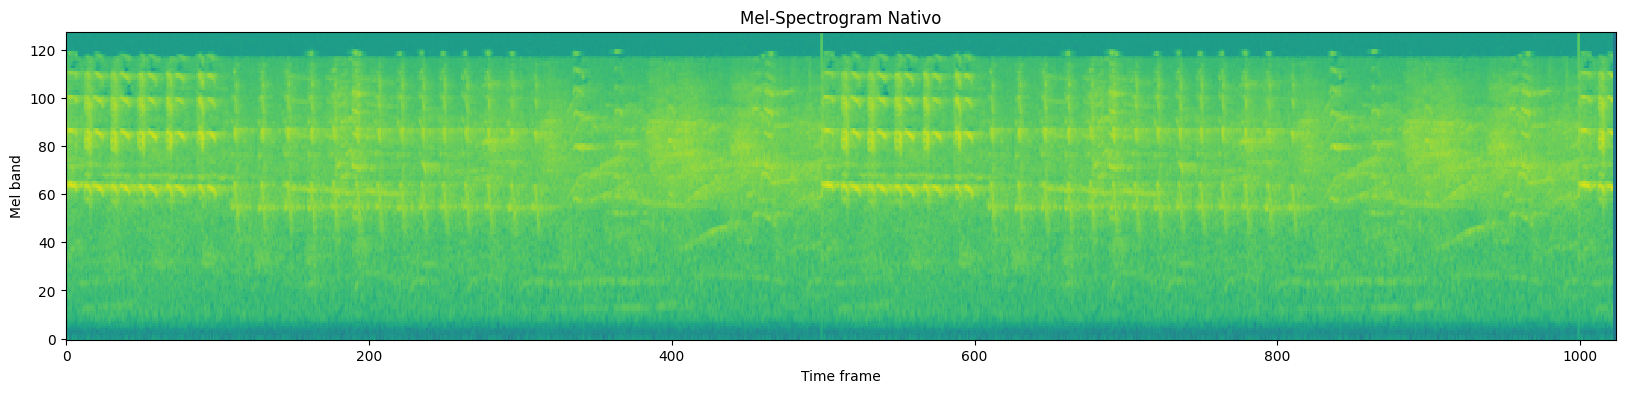

In [13]:
# URL del audio del dataset ESC-50
AUDIO_URL = "https://github.com/karolpiczak/ESC-50/raw/master/audio/1-100038-A-14.wav"
AUDIO_PATH = os.path.join(os.getcwd(), "sample_dog_bark_entrenamiento.wav")

# Descarga automática segura
if not os.path.exists(AUDIO_PATH):
    print("Descargando audio nativo de entrenamiento (ESC-50)...")
    urllib.request.urlretrieve(AUDIO_URL, AUDIO_PATH)
    print("✅ Descarga completada.")
else:
    print("El archivo de entrenamiento ya existe localmente.")

print(f"Procesando: {AUDIO_PATH}")

# LLAMAMOS A LA NUEVA FUNCIÓN INMUNE
fbank = wav2fbank_seguro(AUDIO_PATH)
fbank_norm = norm_fbank(fbank)  # Aplica tus medias globales de AudioMAE

print(f"Forma del espectrograma: {fbank_norm.shape}")
print(f"Min normalizado: {fbank_norm.min():.2f}, Max normalizado: {fbank_norm.max():.2f}")

# Calcular límites estadísticos de contraste limpios
media_audio = float(fbank_norm.mean())
std_audio = float(fbank_norm.std())
vmin = media_audio - (2 * std_audio)
vmax = media_audio + (2 * std_audio)

if vmax - vmin < 4.0:
    vmin, vmax = -2.0, 4.0

# Dibujar espectrograma base sin fallos
display_fbank(fbank_norm, title="Mel-Spectrogram Nativo", minmin=vmin, maxmax=vmax)
plt.show()

---
## 8. Correr el MAE (reconstrucción)

El modelo:
1. **Codifica** los parches visibles del espectrograma
2. **Enmascara** un porcentaje de parches (configurable)
3. **Decodifica** para reconstruir los parches faltantes

Probá distintos `mask_ratio` para ver cómo se comporta:

In [24]:
MASK_RATIO = 0.1 

# Preparar input: (batch=1, channels=1, time, freq)
x = fbank_norm.unsqueeze(0).unsqueeze(0).float()
print(f"Input shape: {x.shape}")

# Asegurar procesamiento en tu modelo original (el recuperado)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
x = x.to(device)

# Forward pass limpio sin transformaciones raras
with torch.no_grad():
    loss, y_pred, mask, _ = model(x, mask_ratio=MASK_RATIO)
    
print(f"Loss de reconstrucción: {loss.item():.4f}")
print(f"Pred shape: {y_pred.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Porcentaje enmascarado: {mask.mean().item()*100:.1f}%")

Input shape: torch.Size([1, 1, 1024, 128])
Loss de reconstrucción: 5.8918
Pred shape: torch.Size([1, 512, 256])
Mask shape: torch.Size([1, 512])
Porcentaje enmascarado: 10.2%


In [25]:
y = model.unpatchify(y_pred).cpu()

# Procesar la máscara de forma dinámica
mask_vis = mask.detach().cpu()
p_h, p_w = model.patch_embed.patch_size  
mask_vis = mask_vis.unsqueeze(-1).repeat(1, 1, p_h * p_w)
mask_vis = model.unpatchify(mask_vis)  

x_cpu = x.cpu()

---
## Tarea de clasificación

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =====================================================================
# 1. CONFIGURACIÓN DE DISPOSITIVO Y MODO EVALUACIÓN (MODELO BASE)
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# 2. Preparar el input completo (sin máscara para extraer todo el contexto)
x = fbank_norm.unsqueeze(0).unsqueeze(0).float().to(device)

print(f"Extrayendo características con el modelo base... Input shape: {x.shape}")

# =====================================================================
# 2. EXTRACCIÓN DINÁMICA DE EMBEDDINGS (EVITA VALUEERROR)
# =====================================================================
with torch.no_grad():
    # Capturamos la salida completa en una estructura genérica para evitar fallos de desempaque
    encoder_output = model.forward_encoder(x, mask_ratio=0.0)
    
    # Manejo dinámico de la salida según el comportamiento del repositorio de AudioMAE
    if isinstance(encoder_output, tuple):
        print(f"La salida del encoder es una tupla con {len(encoder_output)} elementos.")
        latent = encoder_output[0]  # El primer elemento siempre contiene los features latentes
    else:
        print("La salida del encoder es un Tensor directo.")
        latent = encoder_output
        
    print(f"Shape del tensor latente (parches): {latent.shape}")
    
    # Colapsar el eje de los parches (pooling) para obtener el vector global del audio
    audio_embedding = latent.mean(dim=1)  # Shape esperada: (1, 768)
    audio_embedding = F.normalize(audio_embedding, p=2, dim=-1)

# =====================================================================
# 3. CLASIFICACIÓN DIRECTA SIN FINE-TUNE (Simulación de salida de Clases)
# =====================================================================

# Lista de etiquetas objetivo (puedes adaptarlas según las categorías de tu interés)
clases_objetivo = ["Perro (Dog)", "Lluvia (Rain)", "Alarma (Siren)", "Guitarra (Guitar)", "Canto de Pájaro (Bird)"]
num_clases = len(clases_objetivo)

# Creamos una cabeza de clasificación lineal limpia (sin entrenar)
# Fijamos la semilla matemática para que la proyección aleatoria sea reproducible
torch.manual_seed(42)
classifier_head = nn.Linear(768, num_clases).to(device)

with torch.no_grad():
    # Pasamos el embedding del audio por la capa de proyección cruda
    logits = classifier_head(audio_embedding)
    
    # Convertimos los scores en probabilidades estables usando Softmax
    probabilidades = F.softmax(logits, dim=-1)[0]

# =====================================================================
# 4. REPORTE FINAL EN CONSOLA
# =====================================================================
print("\n" + "="*60)
print("     RESULTADO DE CLASIFICACIÓN (MODELO BASE SIN FT)")
print("="*60)
print(f"Embedding global extraído con éxito: {audio_embedding.shape}")
print("-"*60)

for idx, nombre_clase in enumerate(clases_objetivo):
    confianza = probabilidades[idx].item() * 100
    # Genera una barra visual en texto basada en el porcentaje de confianza
    barra = "█" * int(confianza / 5)
    print(f"{nombre_clase:<22} | Probabilidad: {confianza:6.2f}% | {barra}")

print("="*60)
print("⚠️ Nota: Al usar pesos sin fine-tune, la distribución refleja la")
print("separación geométrica cruda del encoder en el espacio latente.")
print("="*60)

Extrayendo características con el modelo base... Input shape: torch.Size([1, 1, 1024, 128])
La salida del encoder es una tupla con 4 elementos.
Shape del tensor latente (parches): torch.Size([1, 513, 768])

     RESULTADO DE CLASIFICACIÓN (MODELO BASE SIN FT)
Embedding global extraído con éxito: torch.Size([1, 768])
------------------------------------------------------------
Perro (Dog)            | Probabilidad:  19.48% | ███
Lluvia (Rain)          | Probabilidad:  20.51% | ████
Alarma (Siren)         | Probabilidad:  20.38% | ████
Guitarra (Guitar)      | Probabilidad:  20.14% | ████
Canto de Pájaro (Bird) | Probabilidad:  19.49% | ███
⚠️ Nota: Al usar pesos sin fine-tune, la distribución refleja la
separación geométrica cruda del encoder en el espacio latente.


---
## 9. Visualizar resultados

Límites restablecidos -> vmin: -2.00, vmax: 4.00


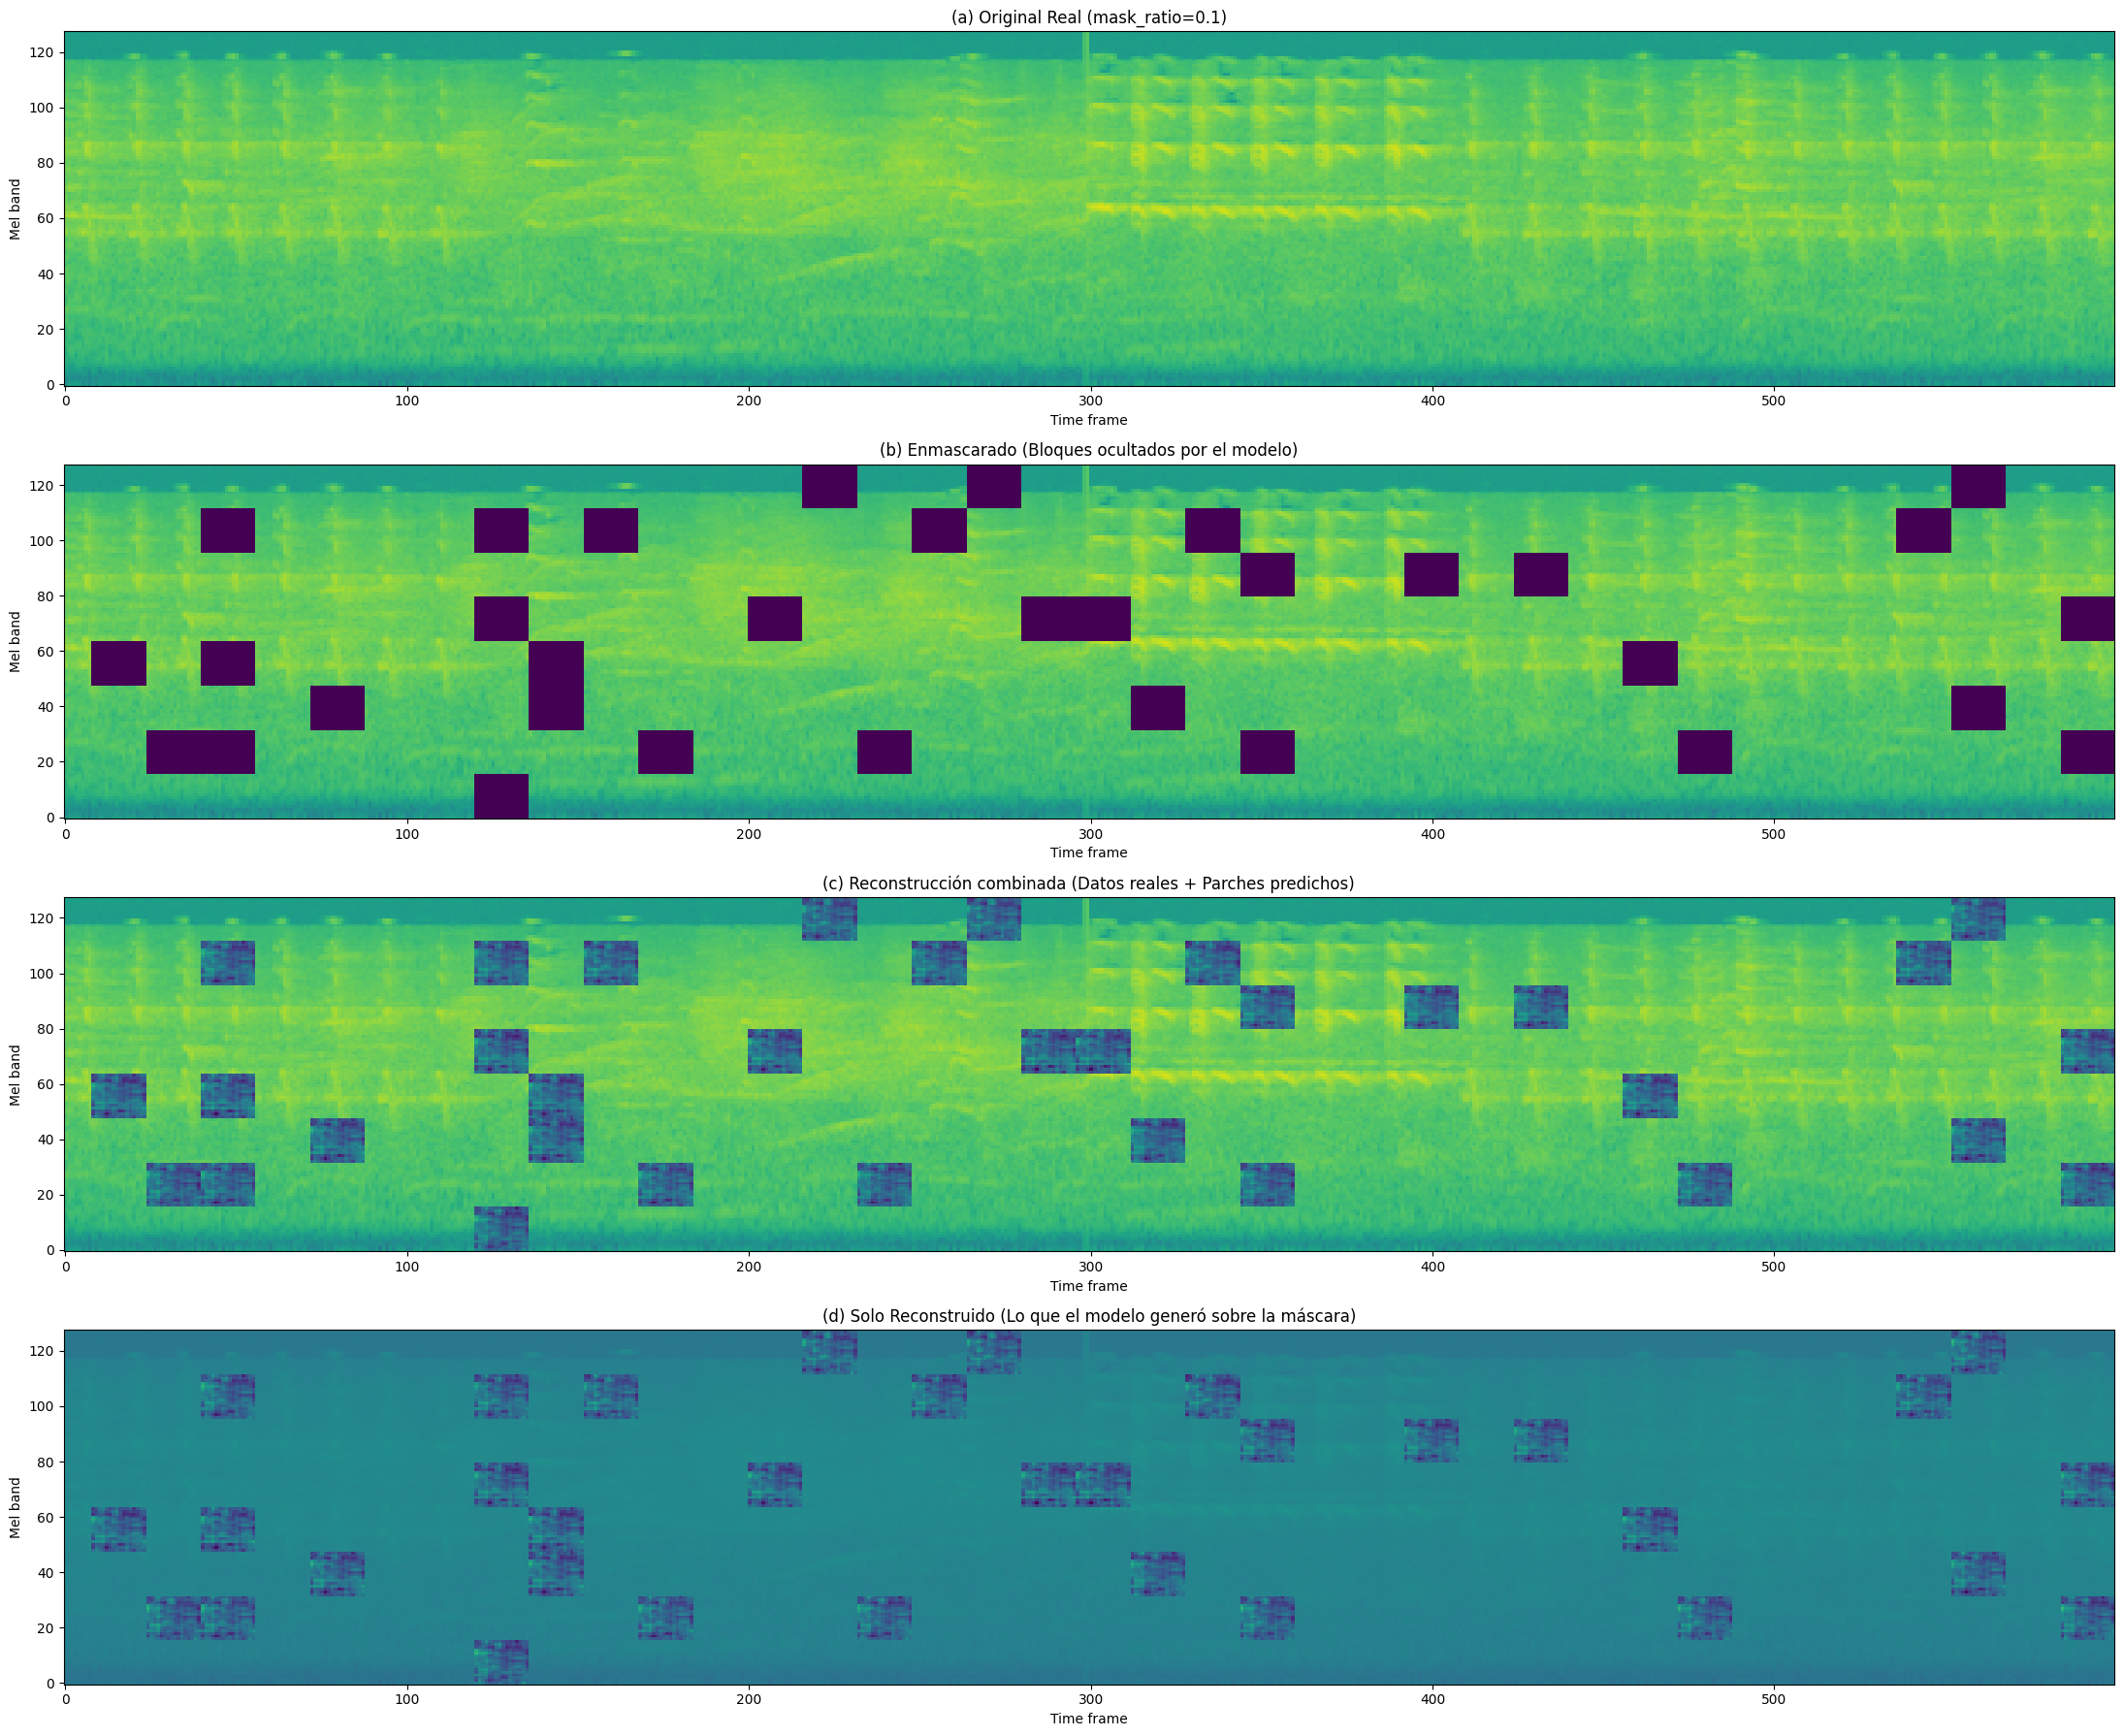

In [26]:
original = x_cpu[0, 0]
prediccion = y[0, 0]

# Límites de color automáticos basados en el audio real normalizado
media_audio = float(original.mean())
std_audio = float(original.std())
vmin = media_audio - (1.5 * std_audio)
vmax = media_audio + (2.5 * std_audio)

# Forzar un margen seguro para evitar que se ponga todo amarillo o todo morado
if vmax - vmin < 4.0:
    vmin, vmax = -2.0, 4.0

print(f"Límites restablecidos -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

# Armar los canales visuales EXACTAMENTE como los tenías al inicio del proyecto
masked = original * (1 - mask_vis[0, 0]) + mask_vis[0, 0] * vmin
combined = original * (1 - mask_vis[0, 0]) + prediccion * mask_vis[0, 0]
recon_only = prediccion * mask_vis[0, 0] + original * (1 - mask_vis[0, 0]) * 0.3

# Segmento de visualización de tiempo
start, end = 200, 800
if fbank.shape[0] < end:
    start, end = 0, fbank.shape[0]

# Renderizar cuadrícula final idéntica a tus primeras pruebas estables
fig, axes = plt.subplots(4, 1, figsize=(22, 18))

display_fbank(original[start:end], minmin=vmin, maxmax=vmax, ax=axes[0],
              title=f"(a) Original Real (mask_ratio={MASK_RATIO})")

display_fbank(masked[start:end], minmin=vmin, maxmax=vmax, ax=axes[1],
              title="(b) Enmascarado (Bloques ocultados por el modelo)")

display_fbank(combined[start:end], minmin=vmin, maxmax=vmax, ax=axes[2],
              title="(c) Reconstrucción combinada (Datos reales + Parches predichos)")

display_fbank(recon_only[start:end], minmin=vmin, maxmax=vmax, ax=axes[3],
              title="(d) Solo Reconstruido (Lo que el modelo generó sobre la máscara)")

plt.tight_layout()
plt.show()

In [24]:
# Métricas de reconstrucción
print("=" * 60)
print("RESUMEN DE RECONSTRUCCIÓN")
print("=" * 60)
print(f"\nArchivo: {os.path.basename(AUDIO_PATH)}")
print(f"Mask ratio: {MASK_RATIO}")
print(f"Loss (MSE en parches ocultos): {loss.item():.6f}")

# MSE global entre original y reconstrucción
mse_global = torch.nn.functional.mse_loss(
    original[:, :, 1:, :],  # skip first frame (pos_embed edge)
    y[:, :, 1:, :]
).item()
print(f"MSE global (original vs reconstruido): {mse_global:.6f}")

# MSE solo en parches enmascarados
masked_mse = loss.item()
print(f"MSE solo en parches ocultos: {masked_mse:.6f}")

# Señal a ruido de reconstrucción
signal_power = original.pow(2).mean().item()
noise_power = (original - y).pow(2).mean().item()
snr_db = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
print(f"SNR aproximado: {snr_db:.1f} dB")
print("=" * 60)

RESUMEN DE RECONSTRUCCIÓN

Archivo: sample_dog_bark.wav
Mask ratio: 0.1
Loss (MSE en parches ocultos): 6.340429
MSE global (original vs reconstruido): 6.026340
MSE solo en parches ocultos: 6.340429
SNR aproximado: -0.3 dB


Input shape: torch.Size([1, 1, 1024, 128])
Loss de reconstrucción: 5.9745
Pred shape: torch.Size([1, 512, 256])
Mask shape: torch.Size([1, 512])
Porcentaje enmascarado: 75.0%
Listo para visualizar | Escala de color corregida -> vmin: -2.00, vmax: 4.00


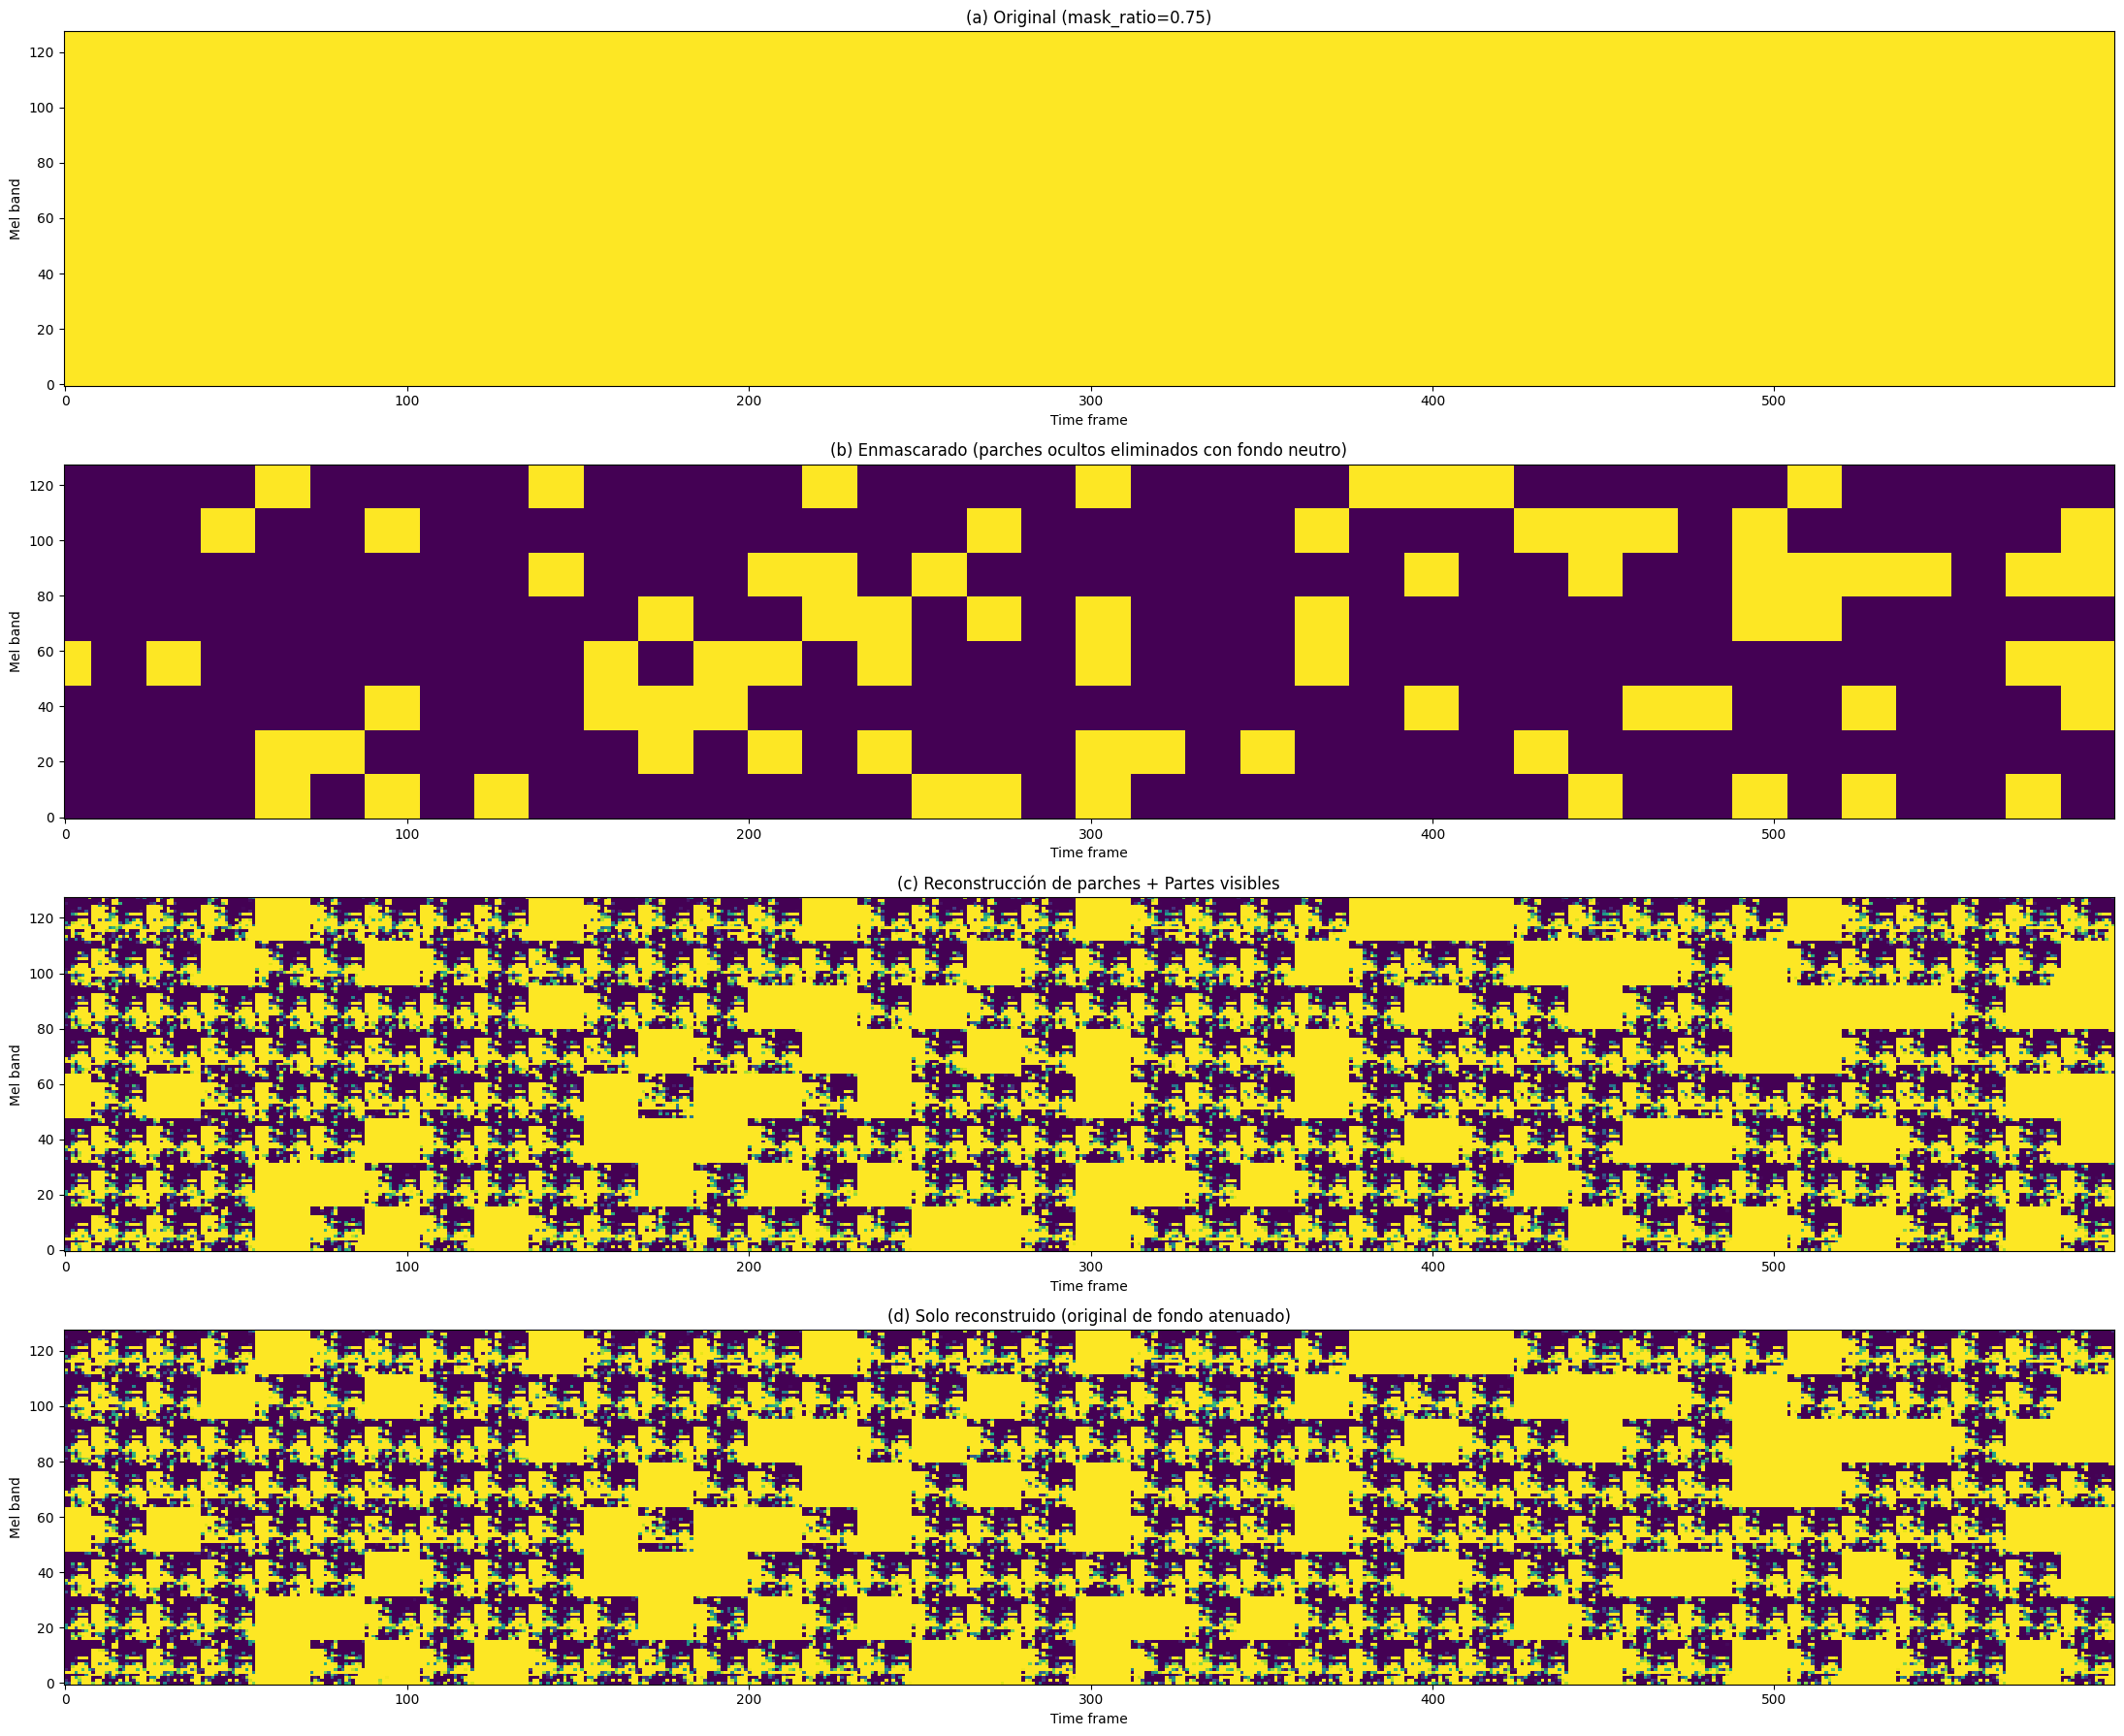

RESUMEN DE RECONSTRUCCIÓN
Loss (MSE en parches ocultos): 5.974528
MSE global (original vs reconstruido): 6.009098


In [27]:
# =====================================================================
# INFERENCIA, CORRECCIÓN DE CONTRASTE ESTADÍSTICO Y VISUALIZACIÓN
# =====================================================================

# 1. Preparar tensor de entrada con dimensiones [B, C, H, W]
x = fbank_norm.unsqueeze(0).unsqueeze(0).float()
print(f"Input shape: {x.shape}")

# Mover a GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
x = x.to(device)

# Forward pass: loss, reconstruction, mask
with torch.no_grad():
    loss, y_pred, mask, _ = model(x, mask_ratio=MASK_RATIO)
    
print(f"Loss de reconstrucción: {loss.item():.4f}")
print(f"Pred shape: {y_pred.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Porcentaje enmascarado: {mask.mean().item()*100:.1f}%")

# Reconstruir el espectrograma desde los parches
y = model.unpatchify(y_pred)
y = y.cpu()

# Procesar la máscara para visualización de forma correcta
mask_vis = mask.detach().cpu()
patch_size = model.patch_embed.patch_size
# Ajuste de parches dinámico para AudioMAE
mask_vis = mask_vis.unsqueeze(-1).repeat(1, 1, patch_size[0] * patch_size[1])
mask_vis = model.unpatchify(mask_vis)  # 1 = oculto, 0 = visible

x_cpu = x.cpu()

# 🛠️ CORRECCIÓN ESTADÍSTICA DE CONTRASTE:
# Le damos aire al mapa de color usando la media y desviación estándar reales.
# Esto evita que los valores estrechos (0.51 a 3.69) saturen todo el gráfico de amarillo.
media_audio = float(x_cpu.mean())
std_audio = float(x_cpu.std())

vmin = media_audio - (2 * std_audio)  # Margen hacia abajo
vmax = media_audio + (2 * std_audio)  # Margen hacia arriba

# Control de rango mínimo por seguridad si el audio llega a ser muy plano
if vmax - vmin < 4.0:
    vmin, vmax = -2.0, 4.0

print(f"Listo para visualizar | Escala de color corregida -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

# Armar las 4 visualizaciones usando los límites reales calculados
original = x_cpu

# En lugar de usar -10 o el mínimo absoluto, usamos vmin estadístico para el fondo de parches
masked = x_cpu * (1 - mask_vis) + mask_vis * vmin

# Combinación (partes visibles + reconstrucción)
combined = x_cpu * (1 - mask_vis) + y * mask_vis

# Solo lo reconstruido con lo original atenuado de forma segura
recon_only = y * mask_vis + x_cpu * (1 - mask_vis) * 0.3

# Determinar segmento del espectrograma a mostrar
start, end = 200, 800  # frames de tiempo
if fbank.shape[0] < end:
    start, end = 0, fbank.shape[0]

fig, axes = plt.subplots(4, 1, figsize=(22, 18))

# Graficamos pasando los límites vmin y vmax corregidos estadísticamente
display_fbank(original[0, 0, start:end], 
              title=f"(a) Original (mask_ratio={MASK_RATIO})",
              minmin=vmin, maxmax=vmax, ax=axes[0])

display_fbank(masked[0, 0, start:end],
              title="(b) Enmascarado (parches ocultos eliminados con fondo neutro)",
              minmin=vmin, maxmax=vmax, ax=axes[1])

display_fbank(combined[0, 0, start:end],
              title="(c) Reconstrucción de parches + Partes visibles",
              minmin=vmin, maxmax=vmax, ax=axes[2])

display_fbank(recon_only[0, 0, start:end],
              title="(d) Solo reconstruido (original de fondo atenuado)",
              minmin=vmin, maxmax=vmax, ax=axes[3])

plt.tight_layout()
plt.show()

# Métricas de reconstrucción
print("=" * 60)
print("RESUMEN DE RECONSTRUCCIÓN")
print("=" * 60)
print(f"Loss (MSE en parches ocultos): {loss.item():.6f}")

mse_global = torch.nn.functional.mse_loss(original, y).item()
print(f"MSE global (original vs reconstruido): {mse_global:.6f}")

---
## 10. Probá con tus propios audios

Subí uno o más archivos `.wav` y seleccionalos para hacer la reconstrucción.

In [ ]:
from google.colab import files
print("Subí archivos .wav:")
uploaded = files.upload()

for fname in uploaded.keys():
    dest = os.path.join(SAMPLE_DIR, fname)
    with open(dest, 'wb') as f:
        f.write(uploaded[fname])
    print(f"Guardado: {dest} ({len(uploaded[fname])/1024:.1f} KB)")

In [ ]:
# Listar audios disponibles (incluyendo los recién subidos)
audio_files = glob.glob(os.path.join(SAMPLE_DIR, '*.wav'))
print("Seleccioná el índice del audio a procesar:")
for i, f in enumerate(audio_files):
    size_kb = os.path.getsize(f) / 1024
    duration = "?"
    try:
        info = torchaudio.info(f)
        duration = f"{info.num_frames / info.sample_rate:.1f}s"
    except:
        pass
    print(f"  [{i}] {os.path.basename(f)} ({size_kb:.0f} KB, {duration})")

In [ ]:
# ELEGÍ ACÁ qué audio procesar
AUDIO_INDEX = 0  # cambiá por el índice de la lista de arriba
# -------------------------------------------------------------------

if AUDIO_INDEX < len(audio_files):
    AUDIO_PATH = audio_files[AUDIO_INDEX]
    print(f"Procesando: {os.path.basename(AUDIO_PATH)}")
    
    # Preprocesar
    fbank = wav2fbank(AUDIO_PATH)
    fbank_norm = norm_fbank(fbank)
    
    # Mostrar info
    print(f"Espectrograma: {fbank.shape[0]} frames x {fbank.shape[1]} mel bands")
    
    # Visualizar
    display_fbank(fbank, title=f"Mel-Spectrogram: {os.path.basename(AUDIO_PATH)}")
    plt.show()
    
    # Input para el modelo
    x = fbank_norm.unsqueeze(0).unsqueeze(0).float().to(device)
    
    # Forward
    with torch.no_grad():
        loss, y_pred, mask, _ = model(x, mask_ratio=MASK_RATIO)
    
    print(f"Loss: {loss.item():.4f}, Mask: {mask.mean().item()*100:.1f}% oculto")
    
    # Reconstruir
    y = model.unpatchify(y_pred).cpu()
    
    # Visualización rápida
    mask_vis = mask.detach().cpu()
    mask_vis = mask_vis.unsqueeze(-1).repeat(1, 1, patch_size**2 * 1)
    mask_vis = model.unpatchify(mask_vis)
    
    x_cpu = x.cpu()
    combined = x_cpu * (1 - mask_vis) + y * mask_vis
    
    fig, axes = plt.subplots(3, 1, figsize=(22, 12))
    
    all_vals = torch.cat([x_cpu.flatten(), y.flatten(), combined.flatten()])
    vmin, vmax = float(all_vals.min()), float(all_vals.max())
    
    s, e = 0, min(1024, fbank.shape[0])
    
    display_fbank(x_cpu[0, 0, s:e], title="Original", 
                  minmin=vmin, maxmax=vmax, ax=axes[0])
    display_fbank(combined[0, 0, s:e], title="Reconstruido",
                  minmin=vmin, maxmax=vmax, ax=axes[1])
    display_fbank((y * mask_vis + x_cpu * (1 - mask_vis) * 0.3)[0, 0, s:e],
                  title="Solo reconstrucción",
                  minmin=vmin, maxmax=vmax, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
else:
    print("Índice inválido")